# 0. Importing Necessary Packages

In [2]:
# Set up environment path to ensure Python and system binaries are accessible
# %set_env PATH=/root/anaconda3/bin:/root/anaconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/root/.fzf./bin

# Print versions of essential packages
from importlib_metadata import version

required_packages = ['numpy', 'matplotlib', 'astropy', 'pandas']
for pkg in required_packages:
    print(f"{pkg}: ver {version(pkg)}")

# Import standard and analysis libraries
import numpy as np
import glob
import os
import pandas as pd
from matplotlib import pyplot as plt
from astropy.io import fits
from acstools import acszpt
from reproject import reproject_interp

numpy: ver 1.26.4
matplotlib: ver 3.9.0
astropy: ver 6.1.2
pandas: ver 2.2.2


# 1. Writing Input Files

## 1) Image list

In [9]:
band = ["F105W", "F160W"]

In [10]:
dir_img = "../1st_TASK_Relics_SMACS/reduced-img/60mas/"
imglist_sub = sorted(glob.glob(dir_img+"*.fits"))
imglist_sub
# imglist = [imglist_sub[15], imglist_sub[24]]
# imglist
 

[]

## 2) Configuration file

In [214]:
config_name = "config.txt"
os.system("sex -dd > "+config_name)

0

## 3) Output parameter file

In [215]:
param_name = "output.param"
f = open(param_name, "w")
f.write("X_IMAGE\n")    # Object position along x [pixel]
f.write("Y_IMAGE\n")    # Object position along y [pixel]
f.write("NUMBER\n")    # Object number
f.write("MAG_AUTO\n")    # Kron-like elliptical aperture magnitude [mag]
f.write("MAGERR_AUTO\n")    # RMS error for MAG_AUTO    [mag]
f.write("MAG_ISO\n") # Isophotal Magnitude
f.write("MAGERR_ISO\n") # Isophotal Magnitude Error
f.write("MAG_ISOCOR\n")
f.write("MAGERR_ISOCOR\n")
f.write("KRON_RADIUS\n")    # Kron apertures in units of A or B
f.write("BACKGROUND\n")    # Background at centroid position
f.write("ALPHA_J2000\n")    # Right ascension of object center (J2000)
f.write("DELTA_J2000\n")    # Declination of object center (J2000)
f.write("A_IMAGE\n")    # Along major axis
f.write("B_IMAGE\n")    # Along minor axis
f.write("THETA_IMAGE\n")    # Position angle
f.write("MU_MAX\n")    # Peak surface brightness above background
f.write("FLAGS\n")    # Extraction flags
f.write("FWHM_IMAGE\n")    # FWHM assuming a gaussian core
f.write("FLUX_RADIUS\n")    # Half-light radii
f.write("CLASS_STAR\n")    # Star/Galaxy classifier output
f.close()

## 4) Determining input parameters

In [216]:
hdr_1 = fits.getheader(imglist[0])
hdr_2 = fits.getheader(imglist[1])

### 4-a) zeropoint calculation from imageheader value

In [217]:
# band = ["F105W", "F160W"]
cat_name = ["{}.cat".format(band[0]), "{}.cat".format(band[1])]
detect_minarea = 9  # DETECT_MINAREA = 5 (default)
detect_thresh = 0.55  #1이었음 # DETECT_THRESH = 1.5 (default)
saturated = 100.0  # SATUR_LEVEL = 100.0 (depending on the image!)
mag0 = [-2.5*np.log10(hdr_1['PHOTFLAM'])-5.0*np.log10(hdr_1['PHOTPLAM'])-2.408,
        -2.5*np.log10(hdr_2['PHOTFLAM'])-5.0*np.log10(hdr_2['PHOTPLAM'])-2.408]
# mag0 = [26.268, 25.946]
egain = [hdr_1['CCDGAIN']*hdr_1['EXPTIME'], hdr_2['CCDGAIN']*hdr_2['EXPTIME']]
# GAIN (effective gain) = gain*exptime (for c/s image) --> this parameter only affects the magnitude error value!
pixel_scale = 0.06  # arcsec/pixel
fwhm = [0.2, 0.2] #이번에 내가 쓰는 reduce img는 0.06arcsec/pixel   # For HST images, seeing FWHMs are typically 3 pixels (~ 0.09 arcsec).
# However, you can directly measure the FWHM value in your image using imexamine or etc.,
# because the FWHM value can also vary with image quality.
back_size = [64, 64]  # BACK_SIZE = 64 (default) --> 32 (revised)
# Smaller BACK_SIZE --> Can subtract more local background --> Can detect more sources
back_filtersize = [3, 3]

checkimg = ["{}_aper.fits".format(band[0]), "{}_aper.fits".format(band[1])]  # CHECKIMAGE_NAME (apertures)
refimg = imglist[0]


deblend_nthresh = [64, 64]
debelnd_mincont = [0.0001, 0.0001]

backphoto_type = "LOCAL"
backphoto_thick = 24

weight_image = ["../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f105w_v1_rms.fits", "../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f160w_v1_rms.fits"]
refimg_rmsmap = weight_image[0]
weight_type = "MAP_RMS" #MAP_RMS, MAP_WEIGHT
weight_gain = "Y"

filtering = "Y"
filter_name = "gauss_1.5_3x3.conv"
# filter_thresh = [0.5, 1.0]

### 4-b) PHOTFLAM / PHOTPLAM calculation by ACS zeropoint calculation system

In [ ]:
''' 
dates = ['2011-07-16']
queries1 = []
queries2 = []
for date in dates:
    q1 = acszpt.Query(date=date, detector='WFC', filt='F606W')
    zpt_table = q1.fetch()
    # Each object has a zpt_table attribute, so we save the instance
    queries1.append(q1)
for date in dates:
    q2 = acszpt.Query(date=date, detector='WFC', filt='F814W')
    zpt_table = q2.fetch()
    # Each object has a zpt_table attribute, so we save the instance
    queries2.append(q2)


hdr_1["PHOTFLAM"]= q1.zpt_table['PHOTFLAM'][0].value
hdr_1["PHOTPLAM"]= q1.zpt_table['PHOTPLAM'][0].value
hdr_2["PHOTFLAM"]= q2.zpt_table['PHOTFLAM'][0].value
hdr_2["PHOTPLAM"]= q2.zpt_table['PHOTPLAM'][0].value
''' 

' \ndates = [\'2011-07-16\']\nqueries1 = []\nqueries2 = []\nfor date in dates:\n    q1 = acszpt.Query(date=date, detector=\'WFC\', filt=\'F606W\')\n    zpt_table = q1.fetch()\n    # Each object has a zpt_table attribute, so we save the instance\n    queries1.append(q1)\nfor date in dates:\n    q2 = acszpt.Query(date=date, detector=\'WFC\', filt=\'F814W\')\n    zpt_table = q2.fetch()\n    # Each object has a zpt_table attribute, so we save the instance\n    queries2.append(q2)\n\n\nhdr_1["PHOTFLAM"]= q1.zpt_table[\'PHOTFLAM\'][0].value\nhdr_1["PHOTPLAM"]= q1.zpt_table[\'PHOTPLAM\'][0].value\nhdr_2["PHOTFLAM"]= q2.zpt_table[\'PHOTFLAM\'][0].value\nhdr_2["PHOTPLAM"]= q2.zpt_table[\'PHOTPLAM\'][0].value\n\n\n'

## 5) Shell script for SExtractor photometry

In [219]:
scr_name = "sephot.sh"
f = open(scr_name, "w")
for i in np.arange(len(band)):
    
    
    
    # Reference image 
    if (imglist[i] == refimg):
        txt = "sex "+imglist[i]+" -c config.txt -CATALOG_NAME "+cat_name[i]+" -PARAMETERS_NAME output.param "
        txt += f"-WEIGHT_GAIN {weight_gain:s} -WEIGHT_IMAGE {weight_image[i]:s} -WEIGHT_TYPE {weight_type:s} "

    # Non-reference image
    else:
        txt = "sex "+refimg+","+imglist[i]+" -c config.txt -CATALOG_NAME "+cat_name[i]+" -PARAMETERS_NAME output.param "
        txt += f"-WEIGHT_GAIN {weight_gain:s} -WEIGHT_IMAGE {refimg_rmsmap:s},{weight_image[i]:s} -WEIGHT_TYPE {weight_type:s} "

    #==== new added param
    txt += f"-BACK_FILTERSIZE {back_filtersize[i]:d} -DEBLEND_NTHRESH {deblend_nthresh[i]:d} -DEBLEND_MINCONT {debelnd_mincont[i]:.5f} -BACKPHOTO_TYPE {backphoto_type:s} -BACKPHOTO_THICK {backphoto_thick:d} "
    txt += f"-FILTER {filtering:s} -FILTER_NAME {filter_name:s} " #filtering part 제대로 적용안되는 듯 하면서 여전히 -FILTER_THRESH {filter_thresh[0]:.4f},{filter_thresh[1]:.4f} "
    #==== origin param
    txt += f"-DETECT_MINAREA {detect_minarea:d} -DETECT_THRESH {detect_thresh:.1f} "
    txt += f"-FILTER_NAME /usr/share/sextractor/default.conv -SATUR_LEVEL {saturated:.1f} "
    txt += f"-MAG_ZEROPOINT {mag0[i]:.4f} -GAIN {egain[i]:.2f} -PIXEL_SCALE {pixel_scale:.2f} "
    txt += f"-SEEING_FWHM {fwhm[i]:.2f} -STARNNW_NAME /usr/share/sextractor/default.nnw -BACK_SIZE {back_size[i]:d} "
    txt += "-CHECKIMAGE_TYPE APERTURES -CHECKIMAGE_NAME "+checkimg[i] # -CHECKIMAGE_TYPE APERTURES 
    txt += "\n"
    
    f.write(txt)
    
    
f.close()

# 2. Running SExtractor

In [220]:
os.system("sh sephot.sh")
# Run this and see the terminal where the Jupyter Notebook is open!

0

In [221]:
# !sex ../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f160w_v1_drz.fits -c config.txt -CATALOG_NAME F160W.cat -PARAMETERS_NAME output.param -WEIGHT_GAIN Y -WEIGHT_IMAGE ../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f160w_v1_rms.fits -WEIGHT_TYPE MAP_RMS -BACK_FILTERSIZE 3 -DEBLEND_NTHRESH 64 -DEBLEND_MINCONT 0.00010 -BACKPHOTO_TYPE LOCAL -BACKPHOTO_THICK 24 -FILTER Y -FILTER_NAME gauss*.conv -DETECT_MINAREA 9 -DETECT_THRESH 1.0 -FILTER_NAME /usr/share/sextractor/default.conv -SATUR_LEVEL 100.0 -MAG_ZEROPOINT 25.9462 -GAIN 5154.37 -PIXEL_SCALE 0.06 -SEEING_FWHM 0.20 -STARNNW_NAME /usr/share/sextractor/default.nnw -BACK_SIZE 64 -CHECKIMAGE_TYPE APERTURES -CHECKIMAGE_NAME F160W_aper.fits
# !sex ../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f160w_v1_drz.fits,../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f105w_v1_drz.fits -c config.txt -CATALOG_NAME F105W.cat -PARAMETERS_NAME output.param -WEIGHT_GAIN Y -WEIGHT_IMAGE ../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f160w_v1_rms.fits,../1st_TASK_Relics_SMACS/reduced-img/60mas/hlsp_relics_hst_wfc3ir-60mas_smacs0723-73_f105w_v1_rms.fits -WEIGHT_TYPE MAP_RMS -BACK_FILTERSIZE 3 -DEBLEND_NTHRESH 64 -DEBLEND_MINCONT 0.00010 -BACKPHOTO_TYPE LOCAL -BACKPHOTO_THICK 24 -FILTER Y -FILTER_NAME gauss*.conv -DETECT_MINAREA 9 -DETECT_THRESH 1.0 -FILTER_NAME /usr/share/sextractor/default.conv -SATUR_LEVEL 100.0 -MAG_ZEROPOINT 26.2688 -GAIN 3779.35 -PIXEL_SCALE 0.06 -SEEING_FWHM 0.20 -STARNNW_NAME /usr/share/sextractor/default.nnw -BACK_SIZE 64 -CHECKIMAGE_TYPE APERTURES -CHECKIMAGE_NAME F105W_aper.fits


# 3. Reading the Data

In [11]:
# colnames 정의 및 상대 경로와 band list를 사용하여 SExtractor 카탈로그 파일 읽기
colnames = [
    'x','y','num','mag_auto','magerr_auto','mag_iso','magerr_iso',
    'mag_isocor','magerr_isocor','kron','backgr','ra','dec',
    'a','b','theta','mu0','flag','fwhm','flxrad','cl'
]

dat_0 = np.genfromtxt(f'../RESULT/60mas/F105W-F160W/Threshold_Low/{band[0]}.cat', dtype=None, encoding='ascii', names=colnames)
dat_1 = np.genfromtxt(f'../RESULT/60mas/F105W-F160W/Threshold_Low/{band[1]}.cat', dtype=None, encoding='ascii', names=colnames)

In [12]:
pd.DataFrame(dat_0).head(5)

,x,y,num,mag_auto,magerr_auto,mag_iso,magerr_iso,mag_isocor,magerr_isocor,kron,...,ra,dec,a,b,theta,mu0,flag,fwhm,flxrad,cl
0,2279.9648,1100.4969,1,17.5936,0.0096,17.5547,0.0070,17.5514,0.0070,3.50,...,110.846385,-73.477527,5.236,4.891,-38.93,14.4550,6,15.20,2.874,0.973
1,2229.3779,1142.1075,2,18.9493,0.0052,18.8972,0.0052,18.8914,0.0051,3.50,...,110.849349,-73.476834,4.190,4.084,-81.23,16.0780,2,5.14,2.411,0.977
2,2641.2532,1449.2960,3,20.4501,0.0056,20.4396,0.0055,20.3876,0.0054,3.52,...,110.825215,-73.471714,10.044,8.545,-68.92,19.0310,2,5.08,8.604,0.029
3,2282.3169,1111.5690,4,22.5514,0.0318,22.8898,0.0337,22.8832,0.0335,3.55,...,110.846247,-73.477343,2.162,1.085,86.70,19.7265,3,7.82,2.074,0.997
4,2277.4409,1131.0980,5,24.5617,3.9055,25.7114,0.1899,24.8477,0.1329,8.04,...,110.846533,-73.477017,2.090,1.544,-78.57,23.2512,1,7.90,5.020,0.801


In [13]:
pd.DataFrame(dat_1).head(5)

,x,y,num,mag_auto,magerr_auto,mag_iso,magerr_iso,mag_isocor,magerr_isocor,kron,...,ra,dec,a,b,theta,mu0,flag,fwhm,flxrad,cl
0,2279.9648,1100.4969,1,17.1116,0.0061,16.8147,inf,16.8125,inf,3.50,...,110.846385,-73.477527,5.236,4.891,-38.93,13.7810,7,30.37,2.575,0.981
1,2229.3779,1142.1075,2,18.9285,0.0452,18.8767,inf,18.8687,inf,3.50,...,110.849349,-73.476834,4.190,4.084,-81.23,15.9878,2,3.85,2.751,0.981
2,2641.2532,1449.2960,3,19.9185,0.0035,19.9420,0.0035,19.9003,0.0035,3.52,...,110.825215,-73.471714,10.044,8.545,-68.92,18.5495,2,5.53,8.439,0.029
3,2282.3169,1111.5690,4,22.9239,0.0310,23.2942,inf,23.2799,inf,3.55,...,110.846247,-73.477343,2.162,1.085,86.70,20.1349,3,9.17,2.481,1.000
4,2277.4409,1131.0980,5,23.3313,0.6779,25.6938,0.1554,23.1896,0.0370,8.04,...,110.846533,-73.477017,2.090,1.544,-78.57,22.9365,1,10.76,7.978,0.638


# 4. Galactic Extinction in Magnitude
## Magnitude Correction

In [14]:
A_lambda_f105w = 1.015
A_lambda_f160w = 0.470 
EBV = 0.1893
Extmag_f105w = A_lambda_f105w * EBV
Extmag_f160w = A_lambda_f160w * EBV
dat_0['mag_isocor'] = dat_0['mag_isocor'] - Extmag_f105w #dat_0 : f105w
dat_1['mag_isocor'] = dat_1['mag_isocor'] - Extmag_f160w #dat_1 : f160w

# 5. Plotting the Figures

### 1) RA/DEC , Mag-Magerr

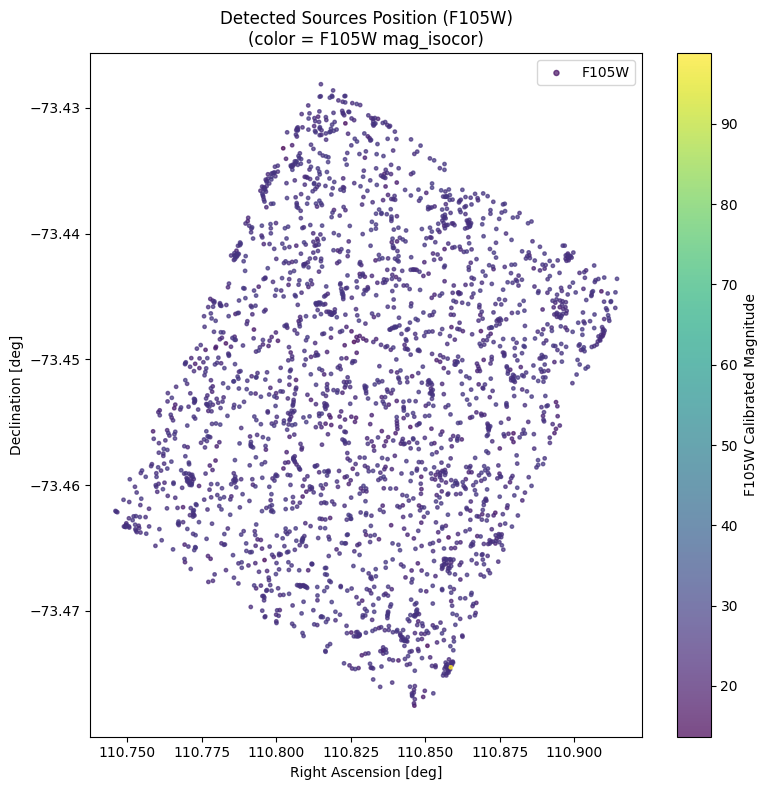

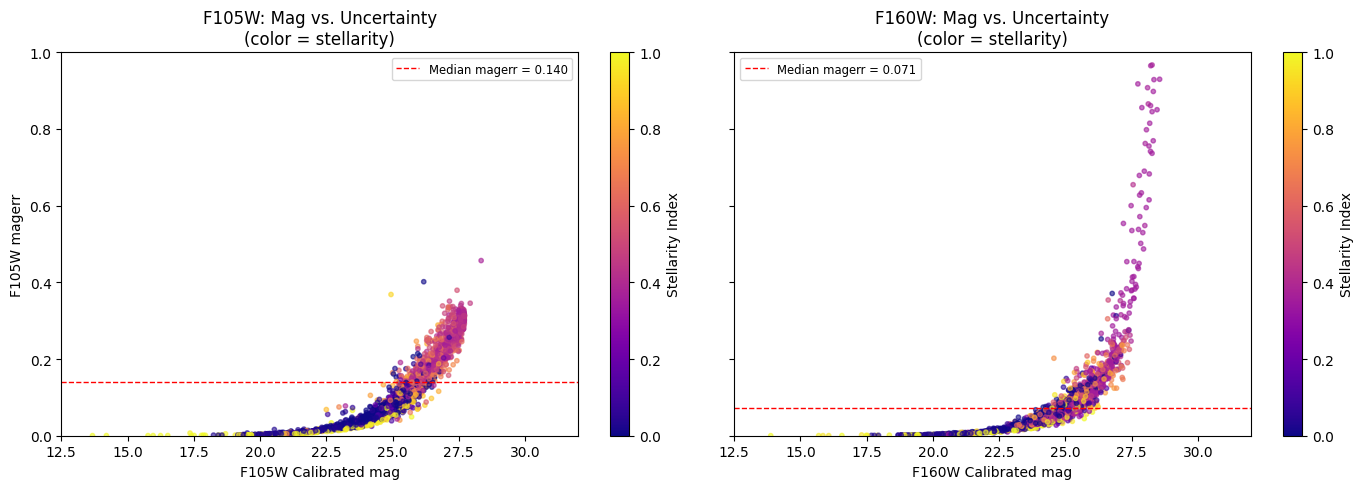

In [17]:
# --- Clean, more informative plotting: positions + mag_err ---

import matplotlib.pyplot as plt

# 1. RA/Dec scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(dat_0['ra'], dat_0['dec'], c=dat_0['mag_isocor'], cmap='viridis', s=6, alpha=0.7, label='F105W')
cb = plt.colorbar(sc, ax=ax, label='F105W Calibrated Magnitude')
ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("Detected Sources Position (F105W)\n(color = F105W mag_isocor)")
ax.legend(markerscale=1.5, fontsize='medium')
plt.tight_layout()
plt.show()

# 2. Mag vs. Magerr for both bands, side-by-side, add median magerr
mag_range = (dat_0['mag_isocor'] < 99.0) & (dat_1['mag_isocor'] < 99.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# F105W
axes[0].scatter(dat_0['mag_isocor'][mag_range], dat_0['magerr_isocor'][mag_range],
                c=dat_0['cl'][mag_range], cmap='plasma', s=10, alpha=0.6)
axes[0].set_xlim([12.5, 32])
axes[0].set_ylim([0.0, 1.0])
axes[0].set_xlabel('F105W Calibrated mag')
axes[0].set_ylabel('F105W magerr')
axes[0].set_title('F105W: Mag vs. Uncertainty\n(color = stellarity)')
cb0 = plt.colorbar(plt.cm.ScalarMappable(cmap='plasma'), ax=axes[0], orientation='vertical', label='Stellarity Index')

mederr_0 = np.median(dat_0['magerr_isocor'][mag_range])
axes[0].axhline(mederr_0, color='red', ls='--', lw=1, label=f'Median magerr = {mederr_0:.3f}')
axes[0].legend(fontsize='small')

# F160W
axes[1].scatter(dat_1['mag_isocor'][mag_range], dat_1['magerr_isocor'][mag_range],
                c=dat_1['cl'][mag_range], cmap='plasma', s=10, alpha=0.6)
axes[1].set_xlim([12.5, 32])
axes[1].set_xlabel('F160W Calibrated mag')
axes[1].set_title('F160W: Mag vs. Uncertainty\n(color = stellarity)')
cb1 = plt.colorbar(plt.cm.ScalarMappable(cmap='plasma'), ax=axes[1], orientation='vertical', label='Stellarity Index')

mederr_1 = np.median(dat_1['magerr_isocor'][mag_range])
axes[1].axhline(mederr_1, color='red', ls='--', lw=1, label=f'Median magerr = {mederr_1:.3f}')
axes[1].legend(fontsize='small')

plt.tight_layout()
plt.show()


### 2) Magnitude - stellarity (``CLASS_STAR``) digram

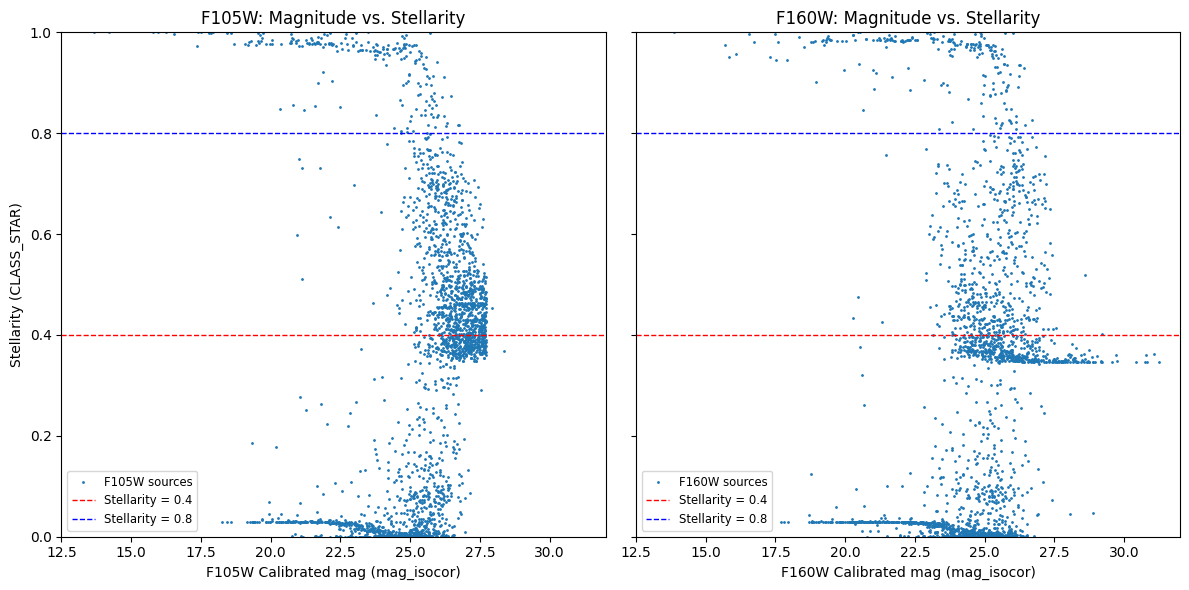

In [19]:
# Plotting Magnitude vs. Stellarity (CLASS_STAR) for F105W and F160W bands side-by-side

# mag_isocor==99.0 marks undetected sources; filter those out of both bands
mag_range = (dat_0['mag_isocor'] < 99.0) & (dat_1['mag_isocor'] < 99.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ---- F105W Magnitude vs. Stellarity ----
axes[0].plot(
    dat_0['mag_isocor'][mag_range],
    dat_0['cl'][mag_range],
    'o',
    ms=1,
    label='F105W sources',
)
axes[0].set_xlim([12.5, 32])
axes[0].set_ylim([0.0, 1.0])
axes[0].set_xlabel('F105W Calibrated mag (mag_isocor)')
axes[0].set_ylabel('Stellarity (CLASS_STAR)')
axes[0].set_title('F105W: Magnitude vs. Stellarity')
# Show generally used CLASS_STAR cutoffs for galaxies (below 0.4) and stars (above 0.8)
axes[0].axhline(0.4, color='red', linestyle='--', linewidth=1, label='Stellarity = 0.4')
axes[0].axhline(0.8, color='blue', linestyle='--', linewidth=1, label='Stellarity = 0.8')
axes[0].legend(loc='lower left', fontsize='small')

# ---- F160W Magnitude vs. Stellarity ----
axes[1].plot(
    dat_1['mag_isocor'][mag_range],
    dat_1['cl'][mag_range],
    'o',
    ms=1,
    label='F160W sources',
)
axes[1].set_xlim([12.5, 32])
axes[1].set_ylim([0.0, 1.0])
axes[1].set_xlabel('F160W Calibrated mag (mag_isocor)')
axes[1].set_title('F160W: Magnitude vs. Stellarity')
axes[1].axhline(0.4, color='red', linestyle='--', linewidth=1, label='Stellarity = 0.4')
axes[1].axhline(0.8, color='blue', linestyle='--', linewidth=1, label='Stellarity = 0.8')
axes[1].legend(loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

### 3) CMDs of galaxies

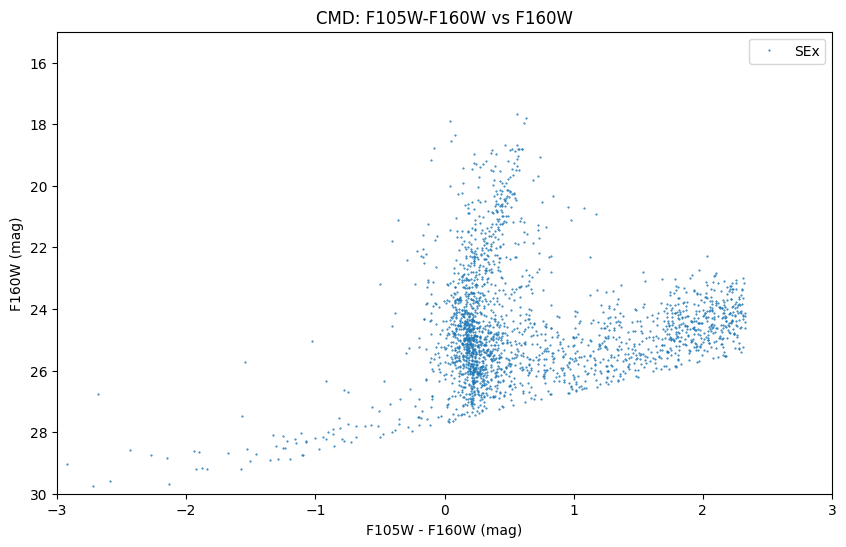

In [21]:
# Cleanly plot the color-magnitude diagram (CMD) of galaxies

# Define selection for likely galaxies:
# - Detected in both bands (mag_isocor < 99.0)
# - Not heavily flagged (flag < 4)
galaxy_mask = (
    (dat_0['mag_isocor'] < 99.0) &
    (dat_1['mag_isocor'] < 99.0) &
    (dat_0['flag'] < 4)
)

# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot color (F105W-F160W) versus magnitude (F160W)
color = dat_0['mag_isocor'][galaxy_mask] - dat_1['mag_isocor'][galaxy_mask]
mag_f160w = dat_1['mag_isocor'][galaxy_mask]
ax.plot(color, mag_f160w, 'o', ms=0.5, label='SEx')

ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.set_xlabel('F105W - F160W (mag)')
ax.set_ylabel('F160W (mag)')
ax.set_title('CMD: F105W-F160W vs F160W')

# Adjust legend marker size
legend = ax.legend()